## Lecture 4

In [1]:
from datascience import *
import numpy as np

%matplotlib inline
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')

In [3]:
nba = Table.read_table('nba_salaries.csv')

In [5]:
type(nba)

datascience.tables.Table

In [7]:
nba.show(6)

rank,name,position,team,salary,season
1,Shaquille O'Neal,C,Los Angeles Lakers,17142000,2000
2,Kevin Garnett,PF,Minnesota Timberwolves,16806000,2000
3,Alonzo Mourning,C,Miami Heat,15004000,2000
4,Juwan Howard,PF,Washington Wizards,15000000,2000
5,Scottie Pippen,SF,Portland Trail Blazers,14795000,2000
6,Karl Malone,PF,Utah Jazz,14000000,2000


* Which team has the highest paid Center (C)
* Which position had the highest average salary?

In [57]:
nba.group('team')

team,count
Atlanta Hawks,281
Bilbao Basket Bilbao Basket,1
Boston Celtics,267
Brooklyn Nets,171
Charlotte Bobcats,162
Charlotte Hornets,150
Chicago Bulls,285
Cleveland Cavaliers,283
Dallas Mavericks,297
Denver Nuggets,285


In [15]:
'''I want to know the highest paid player on the Knicks
1. Get all the players on the Knicks
2. Sort by the Salary
3. Get the largest number
'''
nba.where('team', are.containing('Knicks')).sort('salary', descending=True)

rank,name,position,team,salary,season
9,Carmelo Anthony,PF,New York Knicks,24559380,2017
35,DeAndre Jordan,C,New York Knicks,22897200,2019
3,Carmelo Anthony,PF,New York Knicks,22875000,2016
3,Tracy McGrady,SG,New York Knicks,22843124,2010
3,Carmelo Anthony,PF,New York Knicks,22458401,2015
3,Amar'e Stoudemire,C,New York Knicks,21679893,2014
5,Carmelo Anthony,PF,New York Knicks,21388953,2014
21,Derrick Rose,PG,New York Knicks,21323252,2017
3,Amar'e Stoudemire,C,New York Knicks,19948799,2013
5,Carmelo Anthony,PF,New York Knicks,19444503,2013


In [24]:
knicks = nba.where('team', are.containing('Knicks'))
# knicks.sort('salary', descending=True).take(0).column('name').item(0)
knicks.sort('salary', descending=True).column('name').item(0)

'Carmelo Anthony'

In [27]:
# If we only cared about the highest salary on the Knicks
max(knicks.column('salary'))

24559380

In [28]:
recent_curry = nba.where('season',are.above(2015)).where('name','Stephen Curry')

In [29]:
recent_curry

rank,name,position,team,salary,season
61,Stephen Curry,PG,Golden State Warriors,11370786,2016
82,Stephen Curry,PG,Golden State Warriors,12112359,2017
1,Stephen Curry,PG,Golden State Warriors,37457154,2018
1,Stephen Curry,PG,Golden State Warriors,37457154,2019
1,Stephen Curry,PG,Golden State Warriors,40231758,2020


In [31]:
np.average(recent_curry.select('salary'))

TypeError: the resolved dtypes are not compatible with add.reduce. Resolved (dtype('<U6'), dtype('<U6'), dtype('<U12'))

In [33]:
type(recent_curry.select('salary'))

datascience.tables.Table

In [30]:
np.average(recent_curry.column('salary'))

27725842.199999999

In [35]:
type(recent_curry.column('salary'))

numpy.ndarray

In [2]:
full_census = Table.read_table('nc-est2019-agesex-res.csv')
full_census.show(4)

SEX,AGE,CENSUS2010POP,ESTIMATESBASE2010,POPESTIMATE2010,POPESTIMATE2011,POPESTIMATE2012,POPESTIMATE2013,POPESTIMATE2014,POPESTIMATE2015,POPESTIMATE2016,POPESTIMATE2017,POPESTIMATE2018,POPESTIMATE2019
0,0,3944153,3944160,3951430,3963092,3926570,3931258,3954787,3983981,3954773,3893990,3815343,3783052
0,1,3978070,3978090,3957730,3966225,3977549,3942698,3948891,3973133,4002903,3972711,3908830,3829599
0,2,4096929,4096939,4090621,3970654,3978925,3991740,3958711,3966321,3991349,4020045,3987032,3922044
0,3,4119040,4119051,4111688,4101644,3981531,3991017,4005928,3974351,3982984,4006946,4033038,3998665


In [3]:
partial_census = full_census.select('SEX', 'AGE', 'POPESTIMATE2019').relabeled('POPESTIMATE2019', 'POP')
partial_census.show(3)

SEX,AGE,POP
0,0,3783052
0,1,3829599
0,2,3922044


In [7]:
partial_census.sort('AGE', descending=True)

SEX,AGE,POP
0,999,328239523
1,999,161657324
2,999,166582199
0,100,100322
1,100,23472
2,100,76850
0,99,57124
1,99,14596
2,99,42528
0,98,86150


In [8]:
23472+76850

100322

In [9]:
partial_census.where('SEX', 0).where('AGE', are.below(999))

SEX,AGE,POP
0,0,3783052
0,1,3829599
0,2,3922044
0,3,3998665
0,4,4043323
0,5,4028281
0,6,4017227
0,7,4022319
0,8,4066194
0,9,4061874


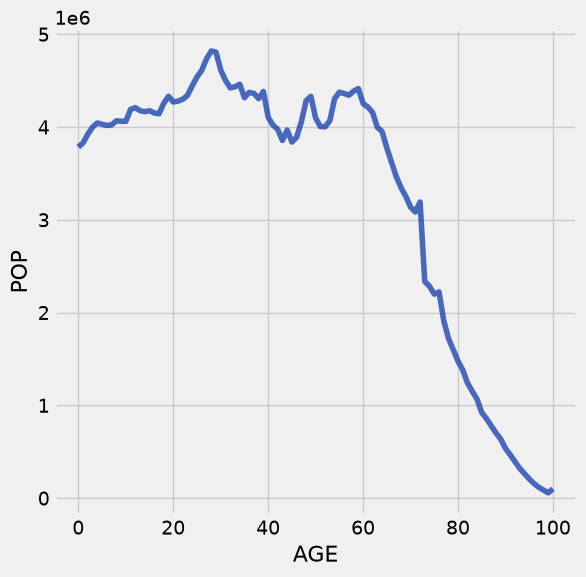

In [45]:
partial_census.where('SEX', 0).where('AGE', are.below(999)).plot('AGE', 'POP')

In [10]:
full_census.select('AGE', 'SEX', 'POPESTIMATE2019', 'POPESTIMATE2011').where('AGE', are.below(999)).where('SEX', 0).drop('SEX')

AGE,POPESTIMATE2019,POPESTIMATE2011
0,3783052,3963092
1,3829599,3966225
2,3922044,3970654
3,3998665,4101644
4,4043323,4121488
5,4028281,4087054
6,4017227,4074531
7,4022319,4082821
8,4066194,4052773
9,4061874,4035319


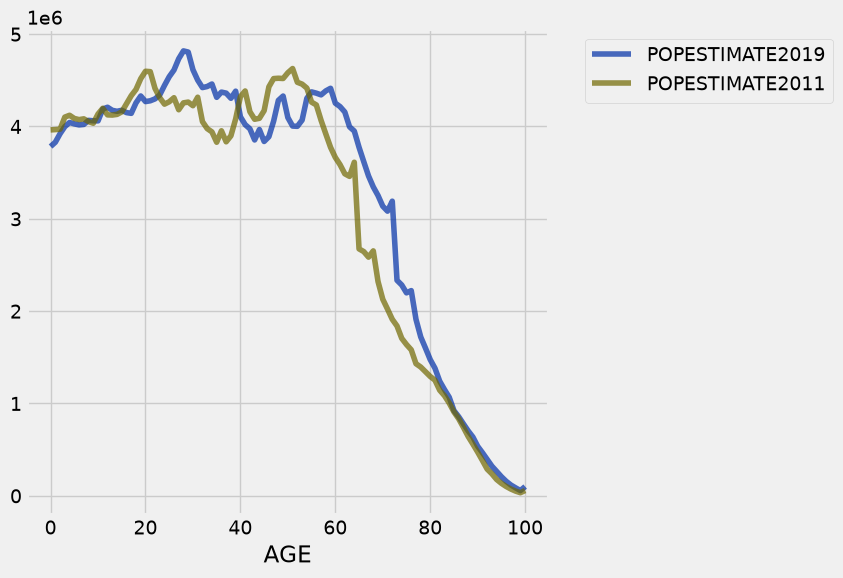

In [47]:
full_census.select('AGE', 'SEX', 'POPESTIMATE2019', 'POPESTIMATE2011').where('AGE', are.below(999)).where('SEX', 0).drop('SEX').plot('AGE')

In [48]:
actors = Table.read_table('actors.csv')
actors

Actor,Total Gross,Number of Movies,Average per Movie,#1 Movie,Gross
Harrison Ford,4871.7,41,118.8,Star Wars: The Force Awakens,936.7
Samuel L. Jackson,4772.8,69,69.2,The Avengers,623.4
Morgan Freeman,4468.3,61,73.3,The Dark Knight,534.9
Tom Hanks,4340.8,44,98.7,Toy Story 3,415
"Robert Downey, Jr.",3947.3,53,74.5,The Avengers,623.4
Eddie Murphy,3810.4,38,100.3,Shrek 2,441.2
Tom Cruise,3587.2,36,99.6,War of the Worlds,234.3
Johnny Depp,3368.6,45,74.9,Dead Man's Chest,423.3
Michael Caine,3351.5,58,57.8,The Dark Knight,534.9
Scarlett Johansson,3341.2,37,90.3,The Avengers,623.4


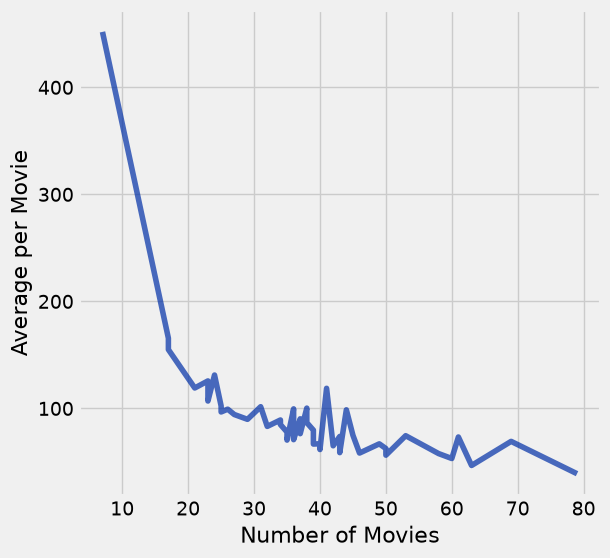

In [49]:
actors.plot('Number of Movies', 'Average per Movie')

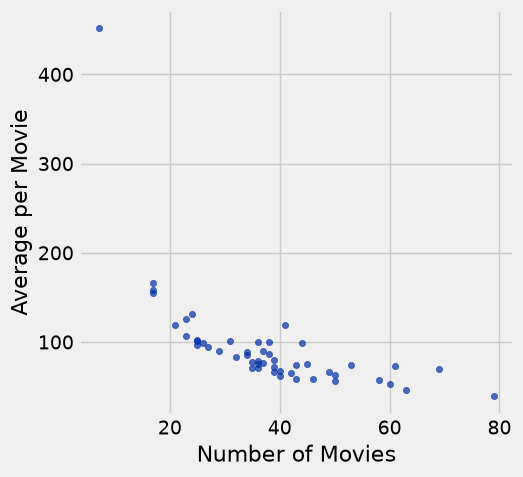

In [50]:
actors.scatter('Number of Movies', 'Average per Movie')

In [51]:
actors.where('Average per Movie', are.above(400))

Actor,Total Gross,Number of Movies,Average per Movie,#1 Movie,Gross
Anthony Daniels,3162.9,7,451.8,Star Wars: The Force Awakens,936.7


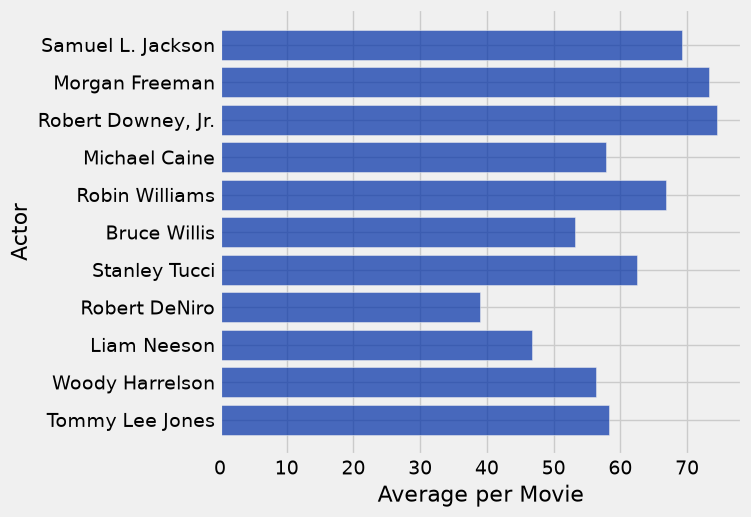

In [56]:
actors.where('Number of Movies', are.above(45)).barh('Actor', 'Average per Movie')